In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Bidirectional
from keras.callbacks import EarlyStopping
import yfinance as yf
from keras.models import load_model

In [71]:
ticker = 'AAPL'
data = yf.download(ticker, start='2010-01-01', end='2024-01-01')

[*********************100%***********************]  1 of 1 completed


In [72]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

In [73]:
train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

In [74]:
def create_dataset(data, time_step=1):
    X, y = [], []
    for i in range(len(data) - time_step - 1):
        a = data[i:(i + time_step), 0]
        X.append(a)
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

In [75]:
time_step = 60
X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

In [76]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [77]:
model = Sequential()
model.add(GRU(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(GRU(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=25))
model.add(Dense(units=1))

In [78]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [79]:
from keras.callbacks import EarlyStopping

In [80]:
early_stopping = EarlyStopping(monitor='val_loss', patience=10)

In [81]:
model.fit(X_train, y_train, batch_size=32, epochs=100, validation_data=(X_test, y_test), callbacks=[early_stopping])

Epoch 1/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.0045 - val_loss: 0.0013
Epoch 2/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 4.5577e-04 - val_loss: 0.0018
Epoch 3/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 4.0552e-04 - val_loss: 7.0717e-04
Epoch 4/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 2.7474e-04 - val_loss: 5.8651e-04
Epoch 5/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 2.7338e-04 - val_loss: 8.7397e-04
Epoch 6/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 2.4623e-04 - val_loss: 5.1925e-04
Epoch 7/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 2.8811e-04 - val_loss: 4.1832e-04
Epoch 8/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 2.4982e-04 - val_loss: 8.1902e-04
Epoch 9/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 3.1208e-04 - val_loss: 6.1800e-04
Epoch 10/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 2.4534e-04 - val_loss: 7.3988e-04
Epoch 11/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 2.3524e-04

In [82]:
model.save('../../utils/Saved_Models/GRU_model.keras')

In [83]:
# Predicting and inverse transforming
predictions = model.predict(X_test)

# Create an array of zeros with the same number of columns as the original data
predictions_extended = np.zeros((predictions.shape[0], scaled_data.shape[1]))

# Replace the 'Close' column with the predictions
predictions_extended[:, 3] = predictions.flatten()  # Assuming 'Close' is the 4th column (index 3)

# Inverse transform the extended predictions
predictions = scaler.inverse_transform(predictions_extended)[:, 3]  # Extract the 'Close' column

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


In [84]:
# Calculating RMSE
y_test_extended = np.zeros((y_test.shape[0], scaled_data.shape[1]))
y_test_extended[:, 3] = y_test  # Assuming 'Close' is the 4th column (index 3)

y_test_inverse = scaler.inverse_transform(y_test_extended)[:, 3]  # Extract the 'Close' column

rmse = np.sqrt(np.mean((predictions - y_test_inverse)**2))
print(f'Root Mean Squared Error: {rmse}')

Root Mean Squared Error: 4.816316212912681


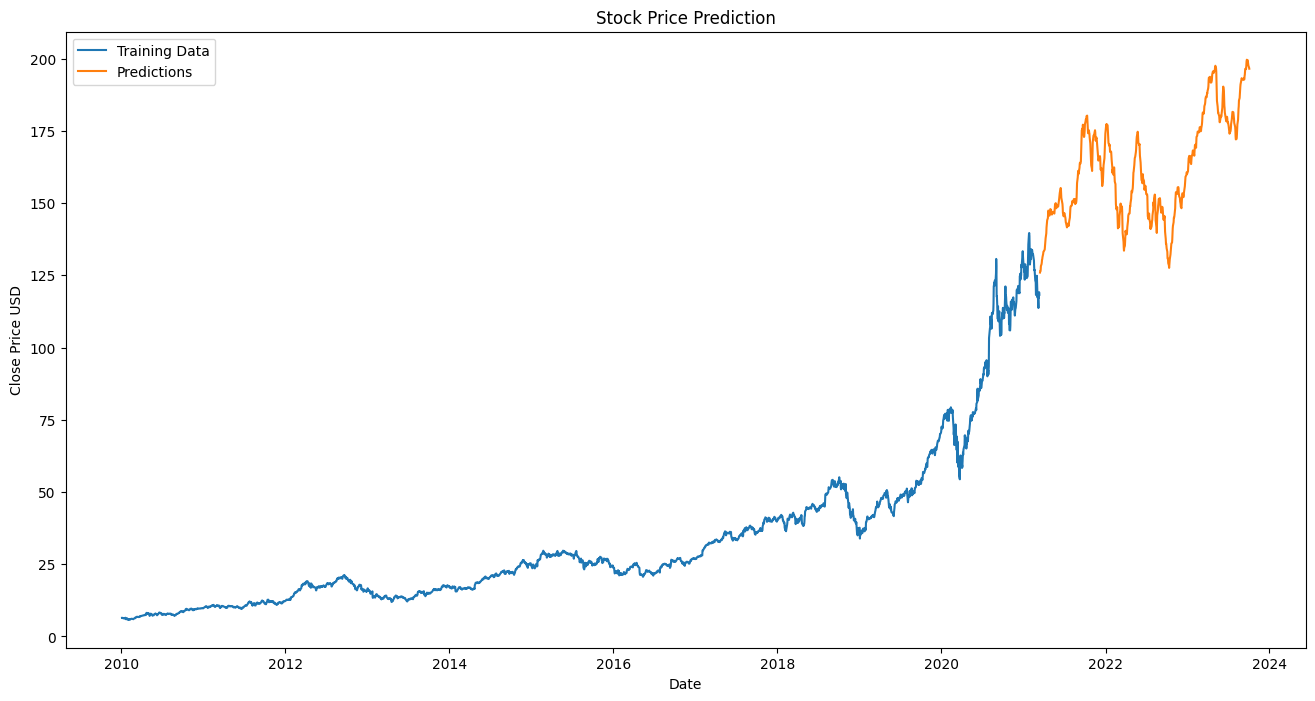

In [85]:
# Plotting the results
train = data[:train_size]
valid = data[train_size:train_size + len(predictions)].copy()
valid['Close'] = predictions.flatten()  # Update valid with predictions

plt.figure(figsize=(16,8))
plt.title('Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Close Price USD')
plt.plot(train['Close'], label='Training Data')
plt.plot(valid['Close'], label='Predictions')
plt.legend()
plt.show()